In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("kidney_disease.csv")

In [3]:
dataset.shape

(400, 26)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [5]:
dataset.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [6]:
def quanqual(dataset):
    quan=[]
    qual=[]
    for columnName in dataset.columns:
        if dataset[columnName].dtype=='O':
            qual.append(columnName)
        else:
            quan.append(columnName)
    return quan,qual

In [7]:
quan,qual=quanqual(dataset)

In [8]:
quan

['id', 'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']

In [9]:
qual

['rbc',
 'pc',
 'pcc',
 'ba',
 'pcv',
 'wc',
 'rc',
 'htn',
 'dm',
 'cad',
 'appet',
 'pe',
 'ane',
 'classification']

In [10]:
dataset.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [11]:
import numpy as np
from sklearn.impute import SimpleImputer
imp_quan=SimpleImputer(missing_values=np.nan,strategy='median')
dataset[quan]=imp_quan.fit_transform(dataset[quan])
imp_qual=SimpleImputer(missing_values=np.nan,strategy='most_frequent')
dataset[qual]=imp_qual.fit_transform(dataset[qual])

In [12]:
qual

['rbc',
 'pc',
 'pcc',
 'ba',
 'pcv',
 'wc',
 'rc',
 'htn',
 'dm',
 'cad',
 'appet',
 'pe',
 'ane',
 'classification']

In [13]:
dataset

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0.0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1.0,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,...,38,6000,5.2,no,no,no,good,no,no,ckd
2,2.0,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,5.2,no,yes,no,poor,no,yes,ckd
3,3.0,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4.0,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395.0,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396.0,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397.0,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398.0,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [14]:
dataset.isnull().sum()

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [15]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Max","Min","25%","50%","75%","100%","IQR","1.5IQR","LesserRange","GreaterRange","Skew","Kurtosis"],columns=quan)
for columnName in quan:
    descriptive.loc["Mean",columnName]=dataset[columnName].mean()
    descriptive.loc["Median",columnName]=dataset[columnName].median()
    descriptive.loc["Mode",columnName]=dataset[columnName].mode()[0]
    descriptive.loc["Max",columnName]=dataset[columnName].max()
    descriptive.loc["Min",columnName]=dataset[columnName].min()

    descriptive.loc["25%",columnName]=dataset.describe()[columnName]["25%"]
    descriptive.loc["50%",columnName]=dataset.describe()[columnName]["50%"]
    descriptive.loc["75%",columnName]=dataset.describe()[columnName]["75%"]
    descriptive.loc["100%",columnName]=dataset.describe()[columnName]["max"]

    descriptive.loc["IQR",columnName]=descriptive.loc["75%",columnName]-descriptive.loc["25%",columnName]
    descriptive.loc["1.5IQR",columnName]=1.5*descriptive.loc["IQR",columnName]
    descriptive.loc["LesserRange",columnName]=descriptive.loc["25%",columnName]-descriptive.loc["1.5IQR",columnName]
    descriptive.loc["GreaterRange",columnName]=descriptive.loc["75%",columnName]+descriptive.loc["1.5IQR",columnName]
    descriptive.loc["Skew",columnName]=dataset[columnName].skew()
    descriptive.loc["Kurtosis",columnName]=dataset[columnName].kurt()

In [16]:
descriptive

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
Mean,199.5,51.5625,76.575,1.017712,0.9,0.395,145.0625,56.693,2.997125,137.63125,4.57725,12.5425
Median,199.5,55.0,80.0,1.02,0.0,0.0,121.0,42.0,1.3,138.0,4.4,12.65
Mode,0.0,55.0,80.0,1.02,0.0,0.0,121.0,42.0,1.2,138.0,4.4,12.65
Max,399.0,90.0,180.0,1.025,5.0,5.0,490.0,391.0,76.0,163.0,47.0,17.8
Min,0.0,2.0,50.0,1.005,0.0,0.0,22.0,1.5,0.4,4.5,2.5,3.1
25%,99.75,42.0,70.0,1.015,0.0,0.0,101.0,27.0,0.9,135.0,4.0,10.875
50%,199.5,55.0,80.0,1.02,0.0,0.0,121.0,42.0,1.3,138.0,4.4,12.65
75%,299.25,64.0,80.0,1.02,2.0,0.0,150.0,61.75,2.725,141.0,4.8,14.625
100%,399.0,90.0,180.0,1.025,5.0,5.0,490.0,391.0,76.0,163.0,47.0,17.8
IQR,199.5,22.0,10.0,0.005,2.0,0.0,49.0,34.75,1.825,6.0,0.8,3.75


In [17]:
freq_df=pd.DataFrame()
for columnName in qual:
    temp=dataset[columnName].value_counts(dropna=False).reset_index()
    temp.columns=["Category","Frequency"]
    temp["Percentage"]=round(temp["Frequency"]/temp["Frequency"].sum()*100,2)
    temp["Column"]=columnName
    freq_df=pd.concat([freq_df,temp],ignore_index=True)

In [18]:
freq_df.T

,0,1,2,3,4,5,6,7,8,9,...,202,203,204,205,206,207,208,209,210,211
Category,normal,abnormal,normal,abnormal,notpresent,present,notpresent,present,41,52,...,\tno,good,poor,no,yes,no,yes,ckd,notckd,ckd\t
Frequency,353,47,324,76,358,42,378,22,91,21,...,2,318,82,324,76,340,60,248,150,2
Percentage,88.25,11.75,81.0,19.0,89.5,10.5,94.5,5.5,22.75,5.25,...,0.5,79.5,20.5,81.0,19.0,85.0,15.0,62.0,37.5,0.5
Column,rbc,rbc,pc,pc,pcc,pcc,ba,ba,pcv,pcv,...,cad,appet,appet,pe,pe,ane,ane,classification,classification,classification


In [19]:
lesser=[]
greater=[]

for columnName in quan:
    if descriptive.loc["Min",columnName]<descriptive.loc["LesserRange",columnName]:
        lesser.append(columnName)
    if descriptive.loc["Max",columnName]>descriptive.loc["GreaterRange",columnName]:
        greater.append(columnName)

In [20]:
lesser

['age', 'bp', 'sg', 'bgr', 'sod', 'pot', 'hemo']

In [21]:
greater

['bp', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot']

In [22]:
for columnName in quan:
    lower=descriptive.loc["LesserRange",columnName]
    upper=descriptive.loc["GreaterRange",columnName]
    dataset[columnName]=dataset[columnName].clip(lower=lower,upper=upper)

In [23]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Max","Min","25%","50%","75%","100%","IQR","1.5IQR","LesserRange","GreaterRange","Skew","Kurtosis"],columns=quan)
for columnName in quan:
    descriptive.loc["Mean",columnName]=dataset[columnName].mean()
    descriptive.loc["Median",columnName]=dataset[columnName].median()
    descriptive.loc["Mode",columnName]=dataset[columnName].mode()[0]
    descriptive.loc["Max",columnName]=dataset[columnName].max()
    descriptive.loc["Min",columnName]=dataset[columnName].min()

    descriptive.loc["25%",columnName]=dataset.describe()[columnName]["25%"]
    descriptive.loc["50%",columnName]=dataset.describe()[columnName]["50%"]
    descriptive.loc["75%",columnName]=dataset.describe()[columnName]["75%"]
    descriptive.loc["100%",columnName]=dataset.describe()[columnName]["max"]

    descriptive.loc["IQR",columnName]=descriptive.loc["75%",columnName]-descriptive.loc["25%",columnName]
    descriptive.loc["1.5IQR",columnName]=1.5*descriptive.loc["IQR",columnName]
    descriptive.loc["LesserRange",columnName]=descriptive.loc["25%",columnName]-descriptive.loc["1.5IQR",columnName]
    descriptive.loc["GreaterRange",columnName]=descriptive.loc["75%",columnName]+descriptive.loc["1.5IQR",columnName]
    descriptive.loc["Skew",columnName]=dataset[columnName].skew()
    descriptive.loc["Kurtosis",columnName]=dataset[columnName].kurt()

In [24]:
lesser=[]
greater=[]

for columnName in quan:
    if descriptive.loc["Min",columnName]<descriptive.loc["LesserRange",columnName]:
        lesser.append(columnName)
    if descriptive.loc["Max",columnName]>descriptive.loc["GreaterRange",columnName]:
        greater.append(columnName)

In [25]:
lesser

[]

In [26]:
greater

[]

In [27]:
dataset.skew(numeric_only=True)

id      0.000000
age    -0.622206
bp      0.057519
sg     -0.261314
al      1.180088
su      0.000000
bgr     0.908317
bu      0.999847
sc      1.179435
sod    -0.043064
pot     0.152948
hemo   -0.324248
dtype: float64

In [28]:
dataset.kurtosis(numeric_only=True)

id     -1.200000
age    -0.076219
bp     -0.934538
sg     -1.106405
al      0.022784
su      0.000000
bgr    -0.316742
bu     -0.144030
sc     -0.020122
sod     0.475876
pot     0.286696
hemo   -0.277180
dtype: float64

In [29]:
import seaborn as sns

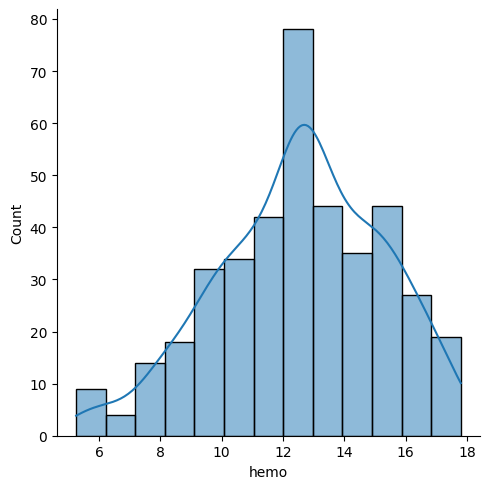

In [30]:
sns.displot(dataset["hemo"], kde=True)

In [31]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='green')
    pyplot.axvline(startrange,color='red')
    pyplot.axvline(endrange,color='red')
    #generate sample
    sample=dataset
    #calc parameters
    sample_mean=sample.mean()
    sample_std=sample.std()
    print("Mean=%3.f,Standard Deviation=%.3f"%(sample_mean,sample_std))
    prob = norm.cdf(endrange, sample_mean, sample_std) - \
           norm.cdf(startrange, sample_mean, sample_std)
    print("The area between the range({},{}):{}".format(startrange,endrange,prob))
    return prob

Mean= 13,Standard Deviation=2.697
The area between the range(10,12):0.24706966630134725


C:\Users\SS\AppData\Local\Temp\ipykernel_12620\3081650658.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='green')


0.24706966630134725

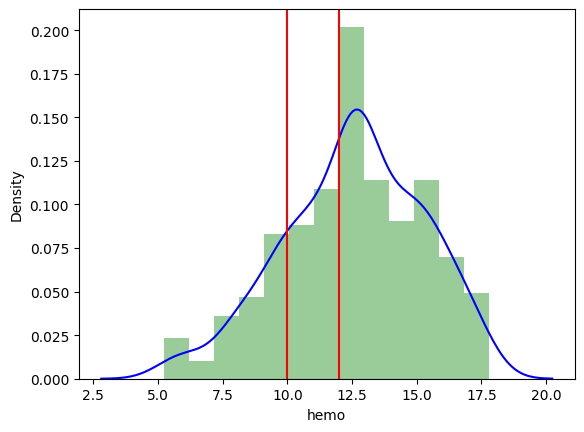

In [32]:
get_pdf_probability(dataset["hemo"],10,12)

In [34]:
from statsmodels.distributions.empirical_distribution import ECDF
ecdf=ECDF(dataset["hemo"])
ecdf(12)

0.3825

In [35]:
def stdNBgraph(dataset):
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()
    values=[i for i in dataset]
    z_scores=[((j-mean)/std) for j in values]
    sns.distplot(z_scores,kde=True)
    sum(z_scores)/len(z_scores)

C:\Users\SS\AppData\Local\Temp\ipykernel_12620\3627566422.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_scores,kde=True)


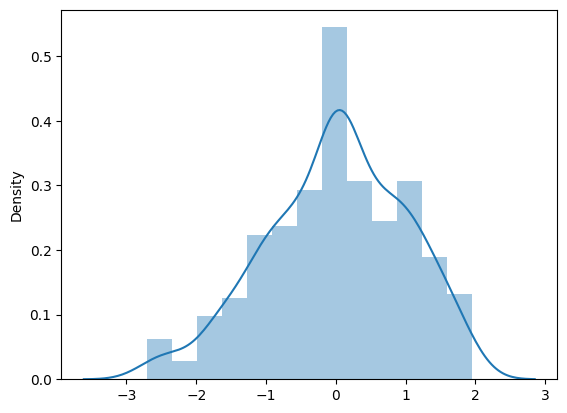

In [36]:
stdNBgraph(dataset["hemo"])